<a href="https://www.kaggle.com/code/lalit7881/car-specifications-eda?scriptVersionId=310541534" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/upcoderr/car-specifications-dataset/car_price_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/upcoderr/car-specifications-dataset/car_price_dataset.csv")

In [3]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [4]:
df.tail()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
1995,1996,Hyundai,2023,4.5,Diesel,Manual,155033,2,3,310,61734.35
1996,1997,Toyota,2023,1.4,Petrol,Manual,25044,2,4,271,48467.80
1997,1998,Hyundai,2022,4.1,Diesel,Manual,104372,4,3,191,55714.40
1998,1999,BMW,2020,4.4,Diesel,Automatic,158047,4,1,186,53222.65
1999,2000,Honda,2012,1.7,Electric,Automatic,19706,3,1,165,40687.70


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


In [6]:
df.describe()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,2013.963000,2.967550,100736.956500,2.988000,2.532500,235.70950,46169.507675
std,577.494589,5.508248,1.146926,56002.915221,0.818041,1.125423,95.59811,9211.685713
min,1.000000,2005.000000,1.000000,5036.000000,2.000000,1.000000,70.00000,18911.550000
25%,500.750000,2009.000000,2.000000,52365.500000,2.000000,2.000000,154.00000,39764.000000
50%,1000.500000,2014.000000,2.900000,100590.500000,3.000000,3.000000,236.00000,46112.350000
75%,1500.250000,2019.000000,4.000000,148024.500000,4.000000,4.000000,319.00000,52471.387500
max,2000.000000,2023.000000,5.000000,199904.000000,4.000000,4.000000,399.00000,72267.800000


In [7]:
df.dtypes

Car_ID            int64
Brand            object
Model_Year        int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Horsepower        int64
Price           float64
dtype: object

In [8]:
df.shape

(2000, 11)

In [9]:
df.isnull().sum()

Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Car_ID', 'Brand', 'Model_Year', 'Engine_Size', 'Fuel_Type',
       'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower',
       'Price'],
      dtype='object')

In [12]:
df.nunique()

Car_ID          2000
Brand              6
Model_Year        19
Engine_Size       41
Fuel_Type          4
Transmission       2
Mileage         1989
Doors              3
Owner_Count        4
Horsepower       329
Price           1998
dtype: int64

## EDA

In [13]:
# Preview
print(df.head())
print(df.info())

   Car_ID    Brand  Model_Year  Engine_Size Fuel_Type Transmission  Mileage  \
0       1     Ford        2023          1.2    Hybrid       Manual   180635   
1       2  Hyundai        2018          3.2  Electric       Manual    35628   
2       3      BMW        2008          2.2    Diesel       Manual    74672   
3       4  Hyundai        2017          2.2    Petrol    Automatic    51246   
4       5  Hyundai        2012          2.4  Electric       Manual   147233   

   Doors  Owner_Count  Horsepower     Price  
0      4            3          82  34309.25  
1      2            4         259  55153.60  
2      3            2         333  41894.40  
3      4            4         381  54046.70  
4      3            4         290  38010.35  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand   

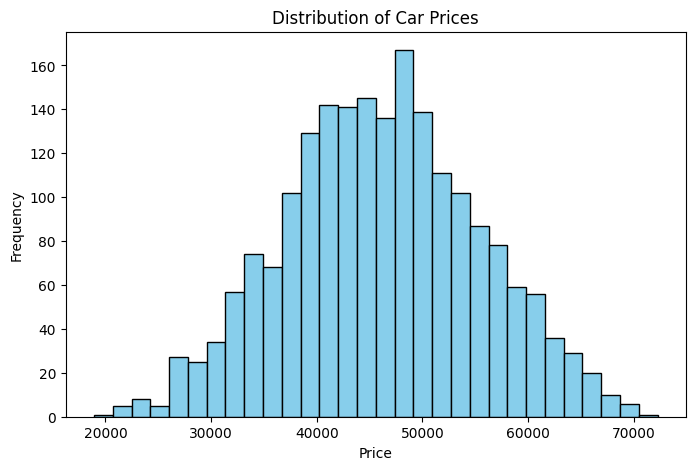

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Price'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

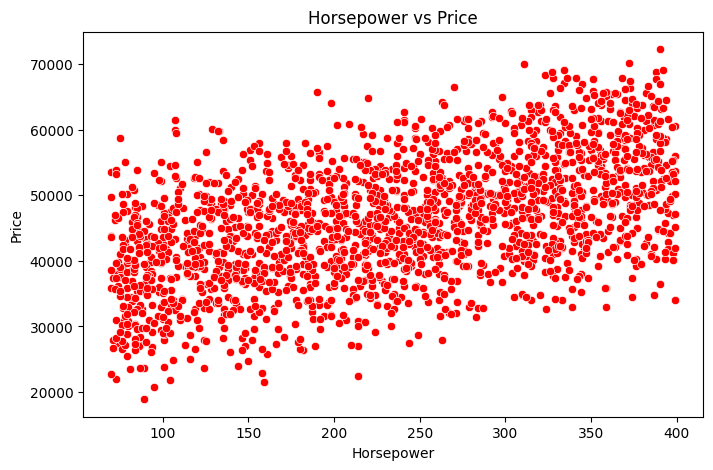

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Horsepower', y='Price', data=df, color='red')
plt.title("Horsepower vs Price")
plt.show()

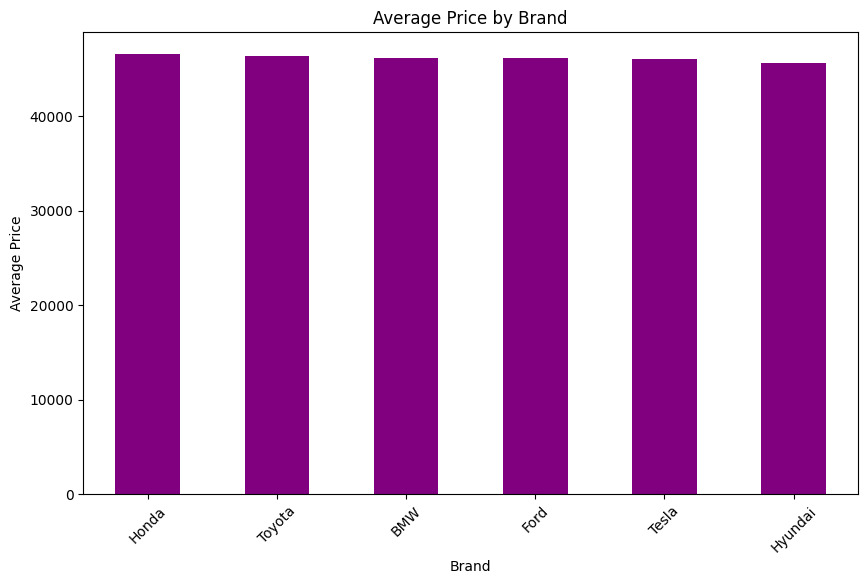

In [16]:
brand_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
brand_price.plot(kind='bar', color='purple')
plt.title("Average Price by Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

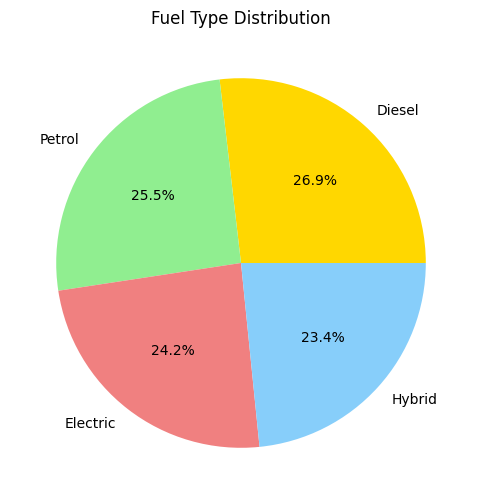

In [17]:
fuel_counts = df['Fuel_Type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%',
        colors=['gold', 'lightgreen', 'lightcoral', 'lightskyblue'])
plt.title("Fuel Type Distribution")
plt.show()

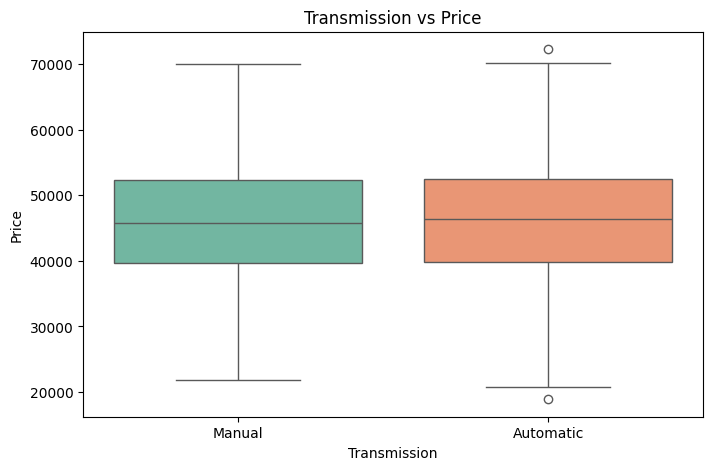

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Transmission', y='Price', data=df,
            palette='Set2')
plt.title("Transmission vs Price")
plt.show()

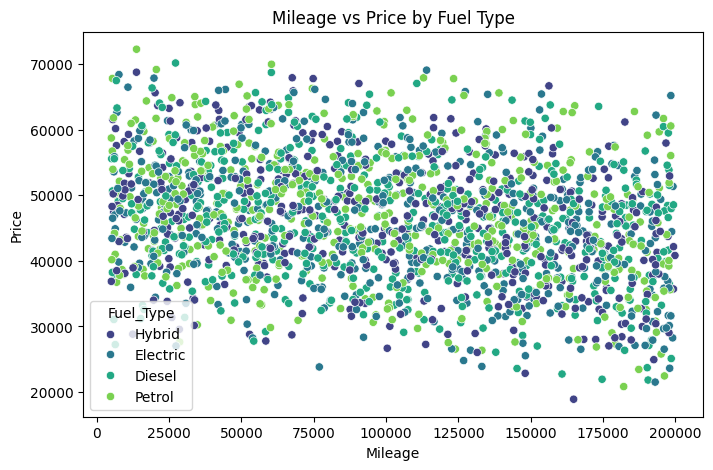

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', hue='Fuel_Type',
                palette='viridis', data=df)
plt.title("Mileage vs Price by Fuel Type")
plt.show()

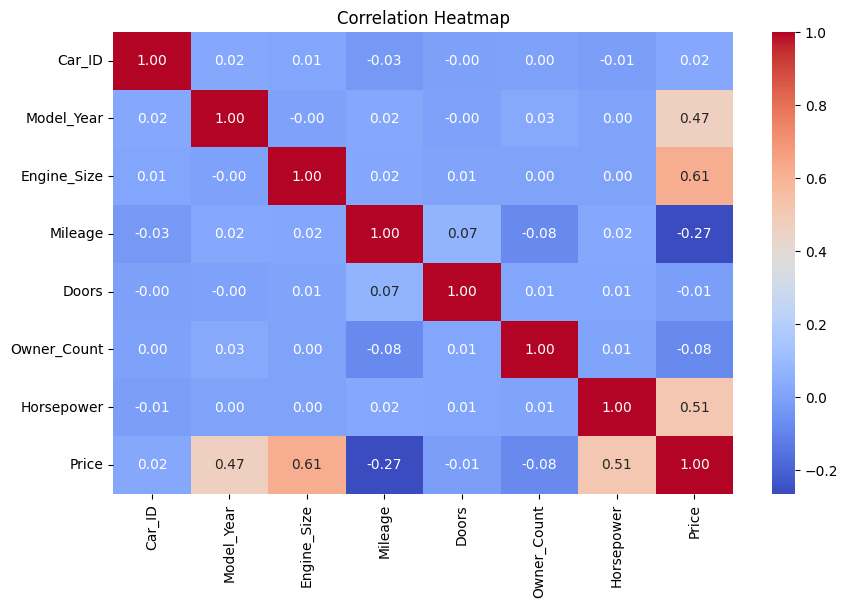

In [20]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

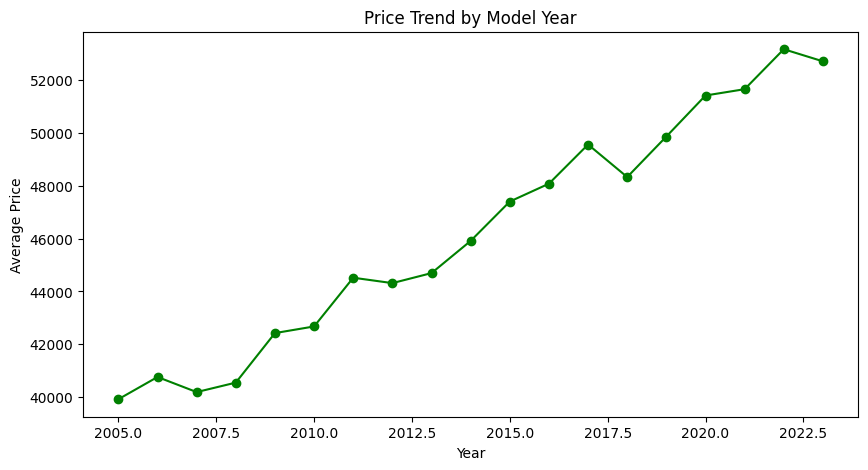

In [21]:
year_price = df.groupby('Model_Year')['Price'].mean()

plt.figure(figsize=(10,5))
plt.plot(year_price.index, year_price.values,
         marker='o', color='green')
plt.title("Price Trend by Model Year")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.show()

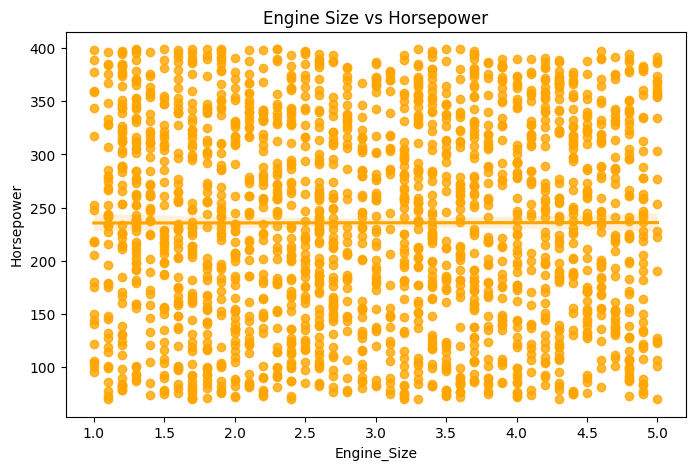

In [22]:
plt.figure(figsize=(8,5))
sns.regplot(x='Engine_Size', y='Horsepower',
            data=df, color='orange')
plt.title("Engine Size vs Horsepower")
plt.show()

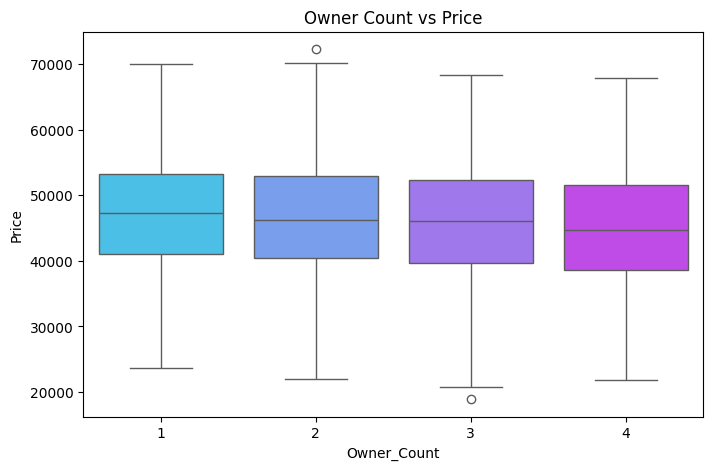

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Owner_Count', y='Price', data=df,
            palette='cool')
plt.title("Owner Count vs Price")
plt.show()

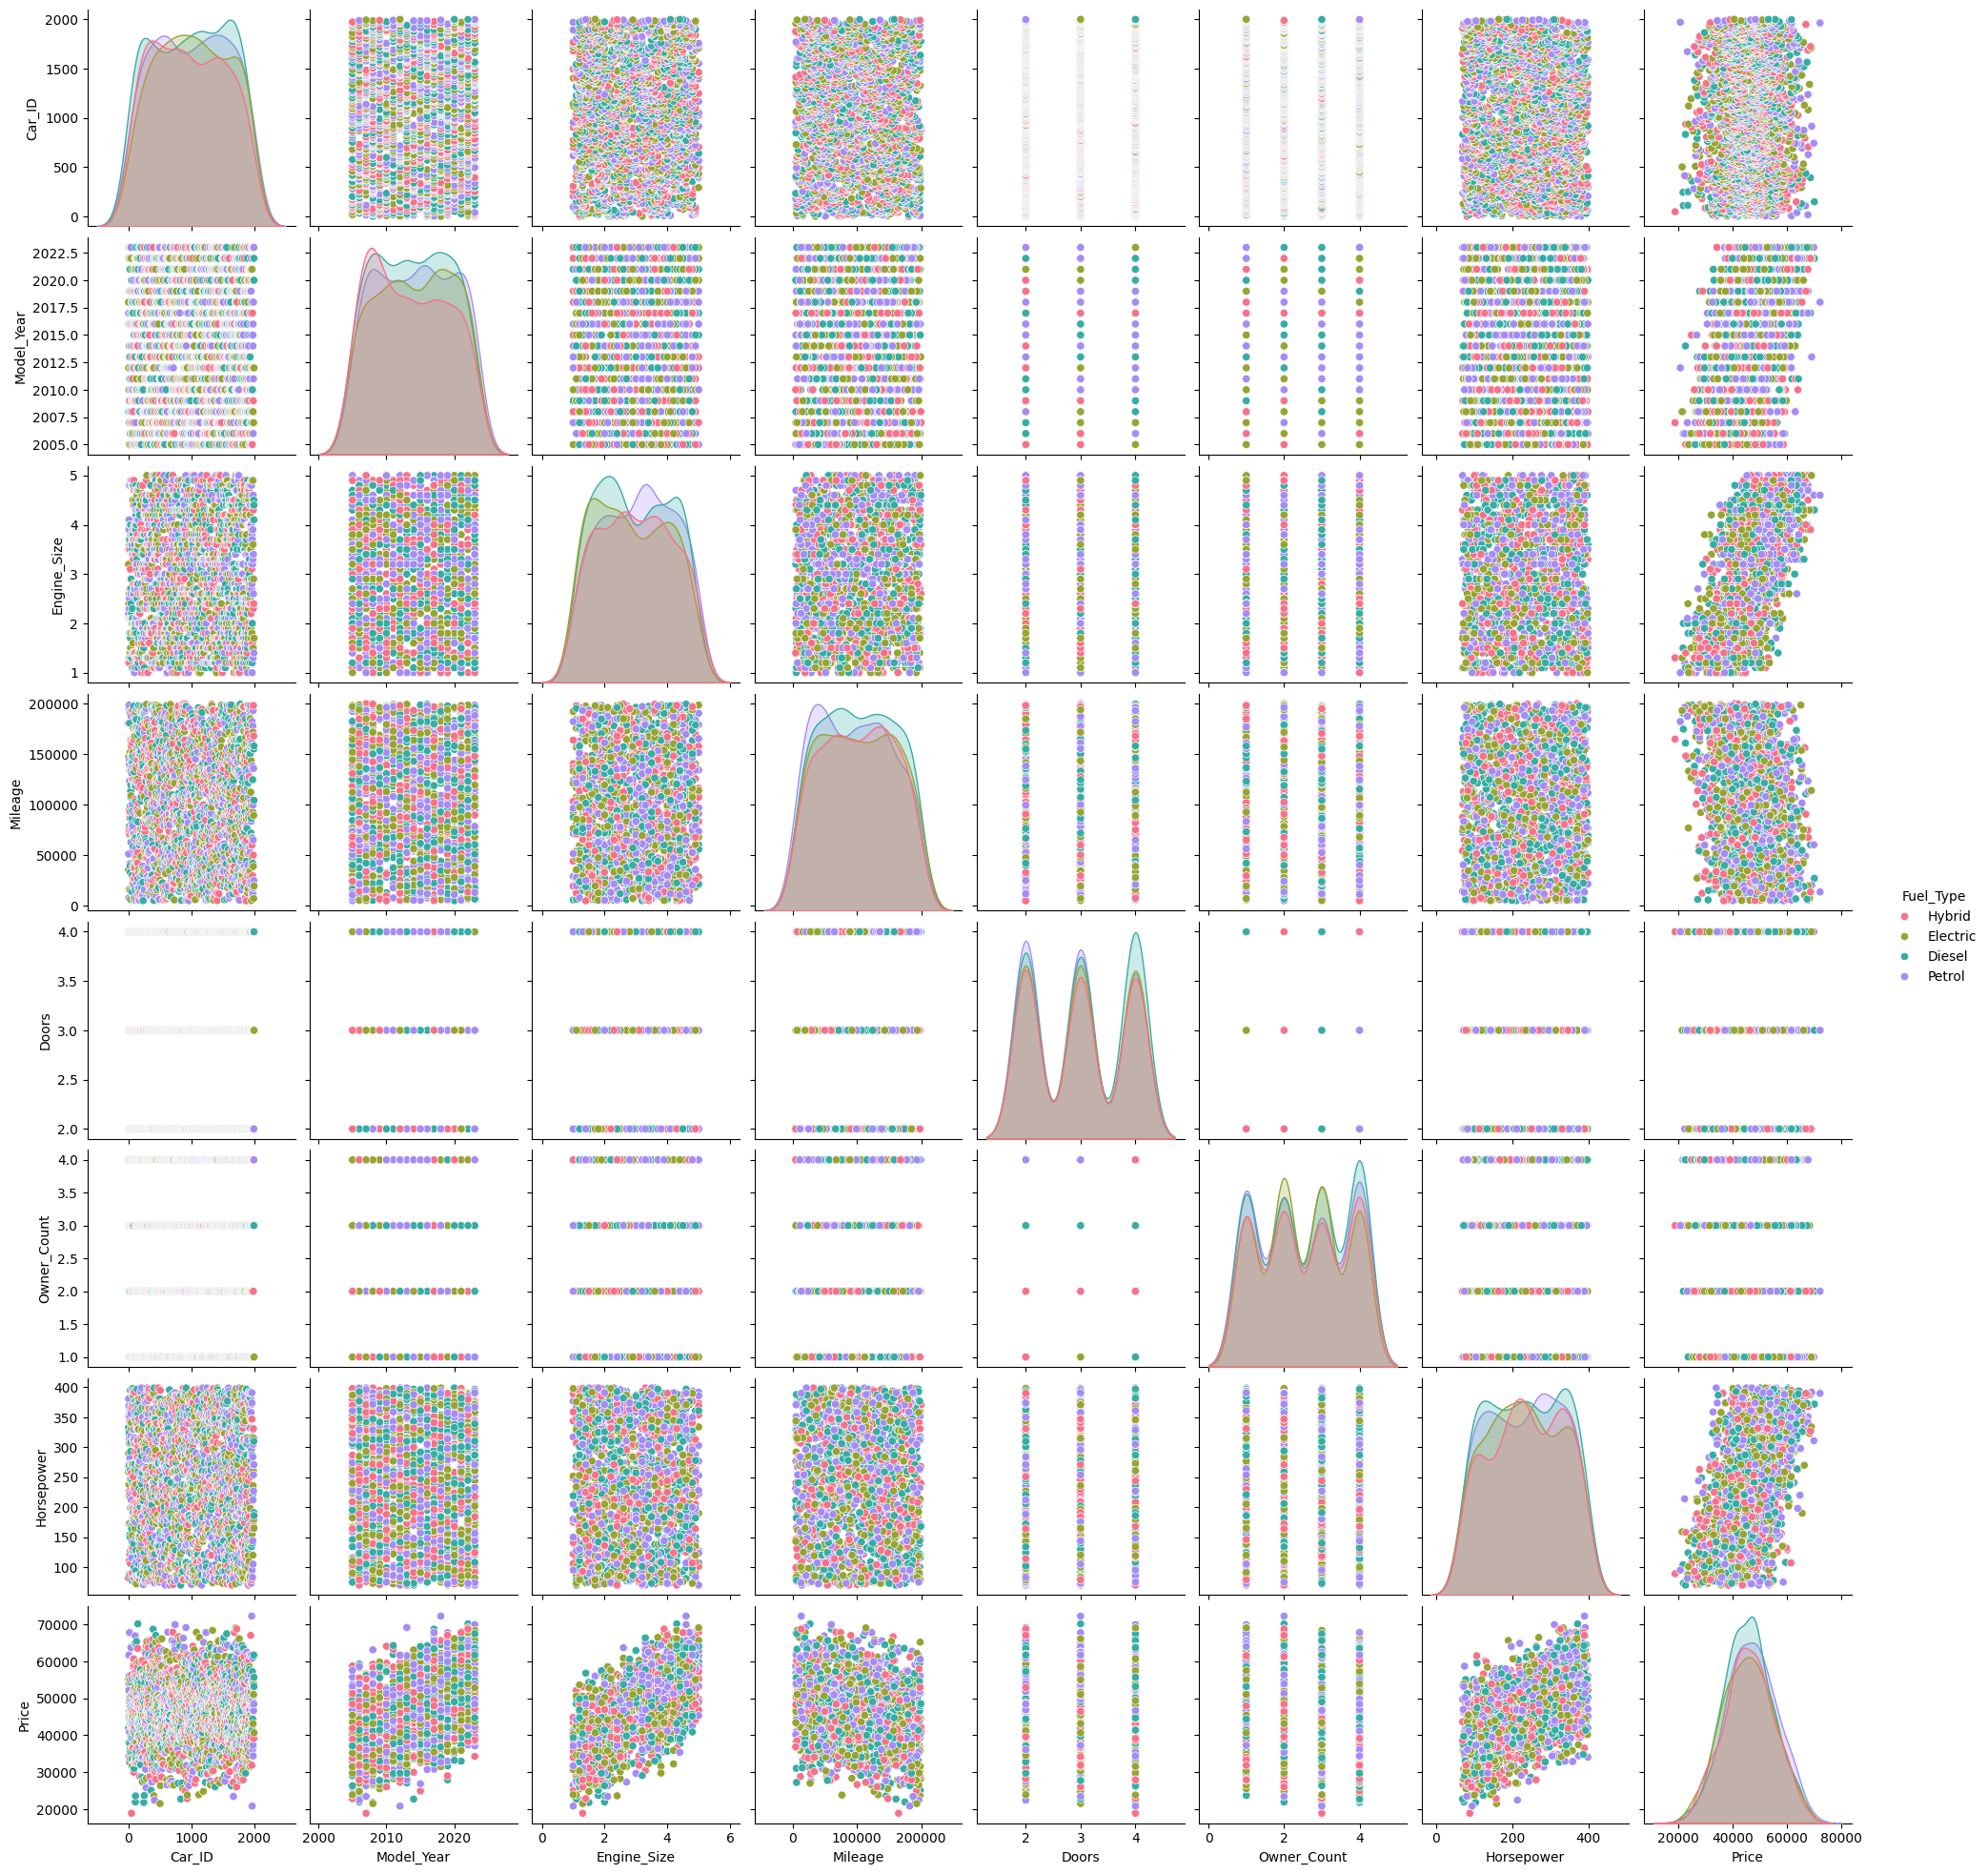

In [24]:
sns.pairplot(df,
             hue='Fuel_Type',
             palette='husl')
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9625
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       200
           1       0.97      0.95      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400


Decision Tree
Accuracy: 0.8525
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       200
           1       0.83      0.88      0.86       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400


Random Forest
Accuracy: 0.9275
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       200
           1       0.95      0.90      0.93       200

    accuracy                           0.93       400
   macro avg       0.93   

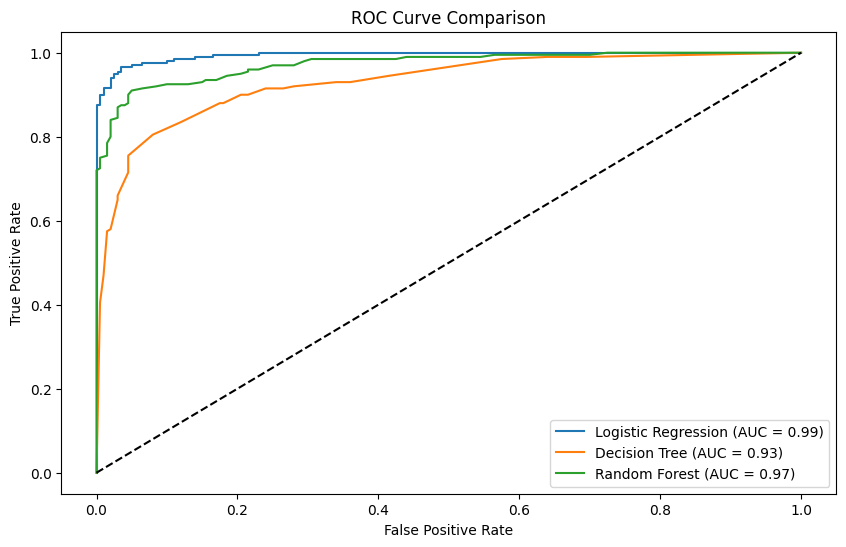


Final Accuracy Comparison:
Logistic Regression: 0.9625
Decision Tree: 0.8525
Random Forest: 0.9275


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# =========================
# 3. Target Creation
# =========================
# Convert Price into classification (High / Low)
df['Price_Category'] = np.where(df['Price'] > df['Price'].median(), 1, 0)

# =========================
# 4. Define Features & Target
# =========================
X = df.drop(['Car_ID', 'Price', 'Price_Category'], axis=1)
y = df['Price_Category']

# =========================
# 5. Identify Column Types
# =========================
categorical_cols = ['Brand', 'Fuel_Type', 'Transmission']
numerical_cols = ['Model_Year', 'Engine_Size', 'Mileage',
                  'Doors', 'Owner_Count', 'Horsepower']

# =========================
# 6. Preprocessing (NO DATA LEAKAGE)
# =========================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# =========================
# 7. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 8. Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# =========================
# 9. Training & Evaluation
# =========================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Pipeline (preprocessing + model)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train ONLY on training data
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================
# 10. Plot ROC Curve
# =========================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# 11. Compare Accuracy
# =========================
print("\nFinal Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

## Thank you..pld